<a href="https://colab.research.google.com/github/jdmartinev/ST1613-AppliedML-/blob/main/Semana04/Penguins_RF_and_GB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación con Random Forest y Gradient Boosting

En este cuaderno aplicaremos ensambles de árboles de decisión tipo random forest y gradient boosting a un [dataset para predecir la especie de algunos pingüinos](https://www.openml.org/d/42585), usando validación cruzada para seleccionar buenos hiperparámetros.

En este notebook aprenderás a aplicar **algoritmos de ensamble** (Random Forest y Gradient Boosting) a un problema de **clasificación**.
Los pasos principales serán:

1. Cargar y limpiar el dataset.
2. Dividir en conjuntos de entrenamiento y prueba con estratificación.
3. Definir pipelines de preprocesamiento y modelos.
4. Buscar hiperparámetros usando validación cruzada.
5. Entrenar y evaluar los modelos.
6. Interpretar resultados mediante métricas y matrices de confusión.
7. Comparar el desempeño de los dos ensambles.

> 🔍 **Nota:** usamos clasificación porque la variable objetivo (`species`), es una categoría (Adelie/Chinstrap/Gentoo). Si fuera un valor numérico emplearíamos regresión en su lugar.

In [18]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, confusion_matrix

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    PolynomialFeatures,
    FunctionTransformer,
)

## Librerías

Importamos varias herramientas de `scikit-learn`:
- `RandomForestClassifier`, `GradientBoostingClassifier` para los modelos.
- `GridSearchCV` para búsqueda de hiperparámetros.
- `Pipeline` y `ColumnTransformer` para encadenar preprocesamiento.
- Escaladores y codificadores para manipular variables numéricas y
  categóricas.
- Métricas y utilidades como `train_test_split`, `f1_score`,
  `ConfusionMatrixDisplay`, etc.

También usamos `pandas`, `numpy` y `matplotlib` para manejo de datos y
visualizaciones.

In [19]:
# Definamos el "random_state" para que los resultados sean reproducibles:
random_state=42

### Reproducibilidad

Definimos una semilla (`random_state`) para que los resultados sean
reproducibles. Esto afecta a la división de datos y a los modelos
aleatorios.

In [20]:
# Cambiemos la fuente de las gráficas de matplotlib:
plt.rc('font', family='serif', size=12)

## Preprocesamiento de datos

En esta sección cargaremos el dataset, exploraremos su contenido,
limpiaremos valores nulos y prepararemos las variables para el modelo.

In [21]:
# Descarguemos nuestro dataset desde OpenML:

data = pd.read_csv("data/penguins.csv")
data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [31]:
data = data.rename(columns={
    "bill_length_mm": "culmen_length_mm",
    "bill_depth_mm": "culmen_depth_mm"
})

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


In [33]:
# Hallemos el número de datos faltantes en cada columna:
data.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [34]:
# Eliminemos las filas con datos faltantes:
data.dropna(axis=0, how='any', inplace=True)

In [35]:
# Verifiquemos que ya no haya datos faltantes en ninguna columna:
data.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [36]:
# Analicemos la distribución de los valores de la columna `island`:
data['island'].value_counts()

island
Biscoe       164
Dream        123
Torgersen     47
Name: count, dtype: int64

In [37]:
# Analicemos la distribución de los valores de la columna `sex`:
data['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [38]:
# Eliminemos la fila donde la columna `sex` es igual a 3:
data.drop(index=data[data['sex'] == 3.0].index, inplace=True)

In [39]:
# Analicemos la distribución de los valores de la etiqueta `species`:
data['species'].value_counts()

species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

A pesar de que varios de los datos aparentan ser numericos, basado en lo que pudimos identificar al usar data.info() , descubirmos que la mayoría de ellos son categoricos, por lo tanto vamos a hacer la conversion a variables numericas de cada una de las caracteristicas

In [40]:
data['culmen_length_mm'] = pd.to_numeric(data['culmen_length_mm'], errors='coerce')
data['culmen_length_mm'] = data['culmen_length_mm'].fillna(0)
data['culmen_depth_mm'] = pd.to_numeric(data['culmen_depth_mm'], errors='coerce')
data['culmen_depth_mm'] = data['culmen_depth_mm'].fillna(0)
data['flipper_length_mm'] = pd.to_numeric(data['flipper_length_mm'], errors='coerce')
data['flipper_length_mm'] = data['flipper_length_mm'].fillna(0)
data['body_mass_g'] = pd.to_numeric(data['body_mass_g'], errors='coerce')
data['body_mass_g'] = data['body_mass_g'].fillna(0)

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


### División de datos

Aquí separamos nuestro dataset en **entrenamiento (80%)** y **prueba
(20%)**.  
Usamos `stratify=data['species']` para mantener la proporción de cada
especie en ambos conjuntos, lo cual es importante en problemas de
clasificación desbalanceados.





In [70]:
# Separemos nuestros datos en conjuntos de entrenamiento y prueba:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(columns='species'),
    data['species'],
    test_size=0.2,
    stratify=data['species'],
    random_state=random_state
)

In [71]:
X_train

,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
205,Dream,50.7,19.7,203.0,4050.0,MALE
164,Dream,47.0,17.3,185.0,3700.0,FEMALE
90,Dream,35.7,18.0,202.0,3550.0,FEMALE
106,Biscoe,38.6,17.2,199.0,3750.0,FEMALE
140,Dream,40.2,17.1,193.0,3400.0,FEMALE
...,...,...,...,...,...,...
24,Biscoe,38.8,17.2,180.0,3800.0,MALE
201,Dream,49.8,17.3,198.0,3675.0,FEMALE
43,Dream,44.1,19.7,196.0,4400.0,MALE
255,Biscoe,48.4,16.3,220.0,5400.0,MALE


### Identificación de columnas numéricas y categóricas

Determinamos qué columnas son numéricas y cuáles son categóricas.
Esto nos permite aplicar transformaciones diferentes a cada tipo de
feature.

In [72]:
#Índices de las columnas numéricas y categ+oricas
cat_cols = X_train.select_dtypes(include=object).columns
num_cols = X_train.select_dtypes(include=np.number).columns

In [73]:
numeric_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

### Configuración de pipelines y búsqueda de hiperparámetros

Creamos pipelines que incluyen el preprocesador y el clasificador. Definimos una grilla de hiperparámetros para `n_estimators`,
`max_depth` y `min_samples_leaf` y usamos `GridSearchCV` con 3 particiones para encontrar la mejor combinación.

In [74]:

# Defineamos los modelos base (un random forest y un gradient boosting):
rf_base = RandomForestClassifier(random_state=random_state)
gb_base = GradientBoostingClassifier(random_state=random_state)

# Definamos la malla de parámetros sobre la que haremos la búsqueda:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': list(range(2, 8)),
    'classifier__min_samples_leaf': [1, 10, 50]
}

pipeline_rf = Pipeline(steps = [
    ('processor', preprocessor),
    ('classifier', rf_base),
                            ])

pipeline_gb = Pipeline(steps = [
    ('processor', preprocessor),
    ('classifier', gb_base),
    ])

# Definamos nuestros modelo mediante GridSearchCV:
rf = GridSearchCV(pipeline_rf, cv=3, param_grid=param_grid)
gb = GridSearchCV(pipeline_gb, cv=3, param_grid=param_grid)


### Configuración de pipelines y búsqueda de hiperparámetros

Creamos pipelines que incluyen el preprocesor y el clasificador.
Definimos una grilla de hiperparámetros para `n_estimators`,
`max_depth` y `min_samples_leaf` y usamos `GridSearchCV` con 3
particiones para encontrar la mejor combinación.

**¿Qué es GridSearchCV?**
GridSearchCV es una técnica de validación cruzada automatizada para
ajustar hiperparámetros. Se construye una malla (grid) con todas las
combinaciones posibles de los valores que queremos probar. Para cada
combinación el método entrena el modelo varias veces (aquí `cv=3` veces)
en diferentes particiones del conjunto de entrenamiento y evalúa el
rendimiento promedio. Al final, el objeto `GridSearchCV` guarda el
modelo ya entrenado con la mejor configuración y nos permite acceder a
los parámetros óptimos mediante `best_params_`.

En este notebook aplicamos la misma búsqueda tanto al pipeline que
contiene un `RandomForestClassifier` como al que contiene un
`GradientBoostingClassifier`. Gracias a GridSearch podemos comparar los
mejores modelos obtenidos para cada técnica y elegir la configuración
más robusta para la clasificación de especies de pingüinos.

## Entrenamiento

Ajustamos los modelos de Random Forest y Gradient Boosting sobre los
datos de entrenamiento. El proceso puede tardar algunos segundos.

In [90]:
#time
# Entrenemos el random forest:
rf.fit(X_train, y_train)
# Entrenemos el gradient boosting:
gb.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('processor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['island', 'sex'], dtype='object'))])),
                                       ('classifier',
                                        GradientBoostingClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [2, 3, 4, 5, 6, 7],
                         'classifier__min_samples_leaf': [1, 10, 50],
                         'classifier__n_estimators': [50, 100]})

In [91]:
# Obtengamos los mejores hiperparámetros encontrados para el random forest:
rf.best_params_

{'classifier__max_depth': 6,
 'classifier__min_samples_leaf': 1,
 'classifier__n_estimators': 100}

In [92]:
# Obtengamos los mejores hiperparámetros encontrados para el gradient boosting:
gb.best_params_

{'classifier__max_depth': 2,
 'classifier__min_samples_leaf': 1,
 'classifier__n_estimators': 100}

### Desempeño en el conjunto de entrenamiento

Calculamos la accuracy y el F1 score utilizando los mejores modelos
encontrados por `GridSearchCV`. Estas métricas nos dan una idea de qué
tan bien encajan los modelos a los datos vistos.

In [78]:
# Obtengamos la accuracy y el F1 score de entrenamiento para cada modelo:
print("Training set")
for model in (rf, gb):
    print(f"Model: {'Random Forest' if model == rf else 'Gradient Boosting'}")
    print(f'Accuracy: {model.score(X_train, y_train)}')
    print(f"F1 score: {f1_score(y_train, model.predict(X_train), average='macro')}")
    print('\n')

Training set
Model: Random Forest
Accuracy: 1.0
F1 score: 1.0


Model: Gradient Boosting
Accuracy: 1.0
F1 score: 1.0




### Evaluación en el conjunto de prueba

Ahora evaluamos los modelos en datos que no vieron durante el ajuste.
Esto nos ayuda a estimar su capacidad de generalización.

In [79]:
# Obtengamos la accuracy y el F1 score de prueba para cada modelo:
print("Test set")
for model in (rf, gb):
    print(f"Model: {'Random Forest' if model == rf else 'Gradient Boosting'}")
    print(f'Accuracy: {model.score(X_test, y_test)}')
    print(f"F1 score: {f1_score(y_test, model.predict(X_test), average='macro')}")
    print('\n')

Test set
Model: Random Forest
Accuracy: 1.0
F1 score: 1.0


Model: Gradient Boosting
Accuracy: 0.9701492537313433
F1 score: 0.9743961352657005




### Matriz de confusión (Random Forest)

La matriz de confusión muestra los aciertos y errores por clase.
Nos ayuda a identificar qué especies se confunden con otras.

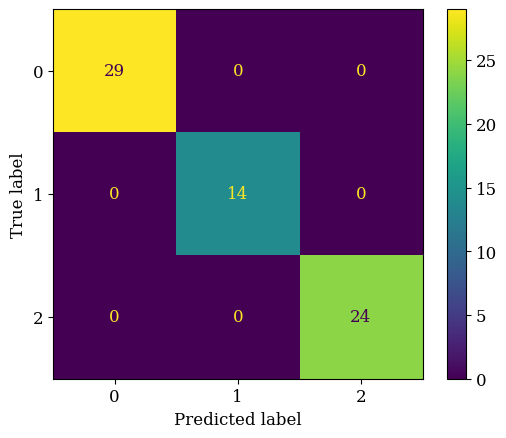

In [80]:
# Grafiquemos la matriz de confusión del random foresr para los datos de prueba (sin normalizar):
cm = confusion_matrix(y_test,rf.predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

### Matriz de confusión (Gradient Boosting)

Repetimos el mismo análisis para el segundo modelo.

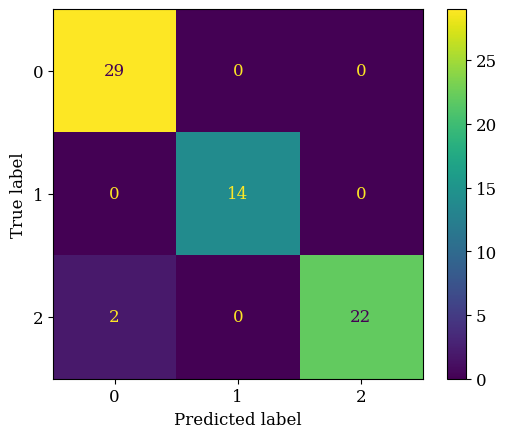

In [81]:
# Grafiquemos la matriz de confusión del gradient boosting para los datos de prueba (sin normalizar):
cm = confusion_matrix(y_test,gb.predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

## Inspección de predicciones

Combinamos las predicciones de ambos modelos con los datos originales
para examinar casos individuales y ver en qué especies difieren las
predicciones.

In [82]:
# Veamos los datos junto con las predicciones de ambos modelos:
pd.concat([
    data.reset_index(drop=True),
    pd.DataFrame({'rf_predicted_species': rf.predict(data.drop(columns='species'))}),
    pd.DataFrame({'gb_predicted_species': gb.predict(data.drop(columns='species'))})
], axis=1)

,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,species,rf_predicted_species,gb_predicted_species
0,Torgersen,39.1,18.7,181.0,3750.0,MALE,Adelie,Adelie,Adelie
1,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,Adelie,Adelie,Adelie
2,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,Adelie,Adelie,Adelie
3,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,Adelie,Adelie,Adelie
4,Torgersen,39.3,20.6,190.0,3650.0,MALE,Adelie,Adelie,Adelie
...,...,...,...,...,...,...,...,...,...
329,Biscoe,47.2,13.7,214.0,4925.0,FEMALE,Gentoo,Gentoo,Gentoo
330,Biscoe,46.8,14.3,215.0,4850.0,FEMALE,Gentoo,Gentoo,Gentoo
331,Biscoe,50.4,15.7,222.0,5750.0,MALE,Gentoo,Gentoo,Gentoo
332,Biscoe,45.2,14.8,212.0,5200.0,FEMALE,Gentoo,Gentoo,Gentoo


## Conclusión

Hemos comparado dos técnicas de ensamble para clasificación de
especies de pingüinos. Observa las métricas y matrices de confusión para
decidir cuál modelo te parece más adecuado, y experimenta cambiando
parámetros o agregando nuevas features.

## Preguntas y ejercicios interactivos

1. ¿Por qué usamos `cv=3` en `GridSearchCV`? ¿Qué pasaría si cambias este
valor a 5 o 10? Propon un experimento y descríbelo.
2. Observa los valores de `best_params_` obtenidos para cada modelo. ¿Qué
te dicen acerca de la complejidad necesaria para clasificar las
especies de pingüinos? ¿Coinciden con tus expectativas?
3. Calcula y comenta **otras métricas de clasificación** (precision,
recall, F1 por clase, matriz normalizada, ROC AUC por etiqueta) para los
dos modelos. ¿Cuál modelo se comporta mejor según estas métricas?
4. Según las matrices de confusión, ¿qué especies son las que más se
confunden? ¿Puedes relacionarlo con alguna feature del dataset?
5. Propon al menos un cambio en el preprocesamiento o en la malla de
parámetros (por ejemplo, agregar `max_features` o ajustar el
escalado) y evalúa cómo afecta las métricas anteriores.

